# Flight Fare Prediction Using Machine Learning
## AmaliTech NSS - Machine Learning Module Lab

**Objective:** Build an end-to-end ML pipeline for predicting flight fares.

**ML Task:** Supervised Regression
**Target Variable:** Price

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Problem Definition & Data Understanding

In [19]:
from src.data_loader import load_dataset, inspect_dataset

df = load_dataset()
summary = inspect_dataset(df)
df.head(10)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90
5,IndiGo,ZYL,"Osmani International Airport, Sylhet",SPD,Saidpur Airport,2025-06-18 18:28:00,2025-06-18 19:33:06,1.085066,Direct,Airbus A320,Business,Travel Agency,5036.394160,200.000000,5236.394160,Regular,70
6,US-Bangla Airlines,SPD,Saidpur Airport,BZL,Barisal Airport,2025-10-25 22:41:00,2025-10-25 23:45:41,1.078155,Direct,Airbus A320,Business,Direct Booking,7397.669874,200.000000,7597.669874,Regular,28
7,AirAsia,JSR,Jessore Airport,LHR,London Heathrow Airport,2025-12-28 01:38:00,2025-12-28 10:30:49,8.880376,1 Stop,Airbus A350,Economy,Online Website,11946.813583,7792.022037,19738.835620,Winter Holidays,12
8,Etihad Airways,SPD,Saidpur Airport,KUL,Kuala Lumpur International Airport,2025-07-06 21:52:00,2025-07-07 01:09:46,3.296282,Direct,Boeing 787,Business,Travel Agency,74973.621871,17246.043281,92219.665152,Regular,23
9,US-Bangla Airlines,DAC,"Hazrat Shahjalal International Airport, Dhaka",DEL,"Indira Gandhi International Airport, Delhi",2025-04-14 23:19:00,2025-04-15 01:54:44,2.595620,Direct,Boeing 787,First Class,Direct Booking,116951.645445,19542.746817,136494.392261,Regular,41


In [20]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  str    
 1   Source                 57000 non-null  str    
 2   Source Name            57000 non-null  str    
 3   Destination            57000 non-null  str    
 4   Destination Name       57000 non-null  str    
 5   Departure Date & Time  57000 non-null  str    
 6   Arrival Date & Time    57000 non-null  str    
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  str    
 9   Aircraft Type          57000 non-null  str    
 10  Class                  57000 non-null  str    
 11  Booking Source         57000 non-null  str    
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Seasonality  

In [21]:
df.describe()

,Duration (hrs),Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Days Before Departure
count,57000.000000,57000.000000,57000.000000,57000.000000,57000.000000
mean,3.994955,58899.556573,11448.238494,71030.316199,45.460579
std,4.094043,68840.614499,12124.344329,81769.199536,26.015657
min,0.500000,1600.975688,200.000000,1800.975688,1.000000
25%,1.003745,8856.316983,200.000000,9602.699787,23.000000
50%,2.644656,31615.996792,9450.940481,41307.544990,45.000000
75%,5.490104,85722.930389,17513.046160,103800.906963,68.000000
max,15.831719,449222.933770,73383.440066,558987.332444,90.000000


In [22]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

Missing values per column:
Airline                  0
Source                   0
Source Name              0
Destination              0
Destination Name         0
Departure Date & Time    0
Arrival Date & Time      0
Duration (hrs)           0
Stopovers                0
Aircraft Type            0
Class                    0
Booking Source           0
Base Fare (BDT)          0
Tax & Surcharge (BDT)    0
Total Fare (BDT)         0
Seasonality              0
Days Before Departure    0
dtype: int64

Total duplicate rows: 0


## Step 2: Data Cleaning & Preprocessing
### 2.1 Cleaning the Data

In [23]:
from src.data_cleaning import clean_dataset

df_clean = clean_dataset(df)
print(f"Shape before cleaning: {df.shape}")
print(f"Shape after cleaning:  {df_clean.shape}")
df_clean.head()

Shape before cleaning: (57000, 17)
Shape after cleaning:  (57000, 17)


,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90


In [24]:
print("Missing values after cleaning:")
print(df_clean.isnull().sum())
print(f"\nDuplicate rows: {df_clean.duplicated().sum()}")
print(f"\nData types:")
print(df_clean.dtypes)

Missing values after cleaning:
Airline                  0
Source                   0
Source Name              0
Destination              0
Destination Name         0
Departure Date & Time    0
Arrival Date & Time      0
Duration (hrs)           0
Stopovers                0
Aircraft Type            0
Class                    0
Booking Source           0
Base Fare (BDT)          0
Tax & Surcharge (BDT)    0
Total Fare (BDT)         0
Seasonality              0
Days Before Departure    0
dtype: int64

Duplicate rows: 0

Data types:
Airline                             str
Source                              str
Source Name                         str
Destination                         str
Destination Name                    str
Departure Date & Time    datetime64[us]
Arrival Date & Time      datetime64[us]
Duration (hrs)                  float64
Stopovers                           str
Aircraft Type                       str
Class                               str
Booking Source           

## Step 3: Exploratory Data Analysis (EDA)
### 3.1 Descriptive Statistics

In [25]:
from src.eda import summarize_fares, compute_kpis

fare_summary = summarize_fares(df_clean)
fare_summary

,Mean,Median,Std,Min,Max,Count
Airline,,,,,,
Turkish Airlines,75547.27,43172.68,86133.38,1842.79,558987.33,2220
AirAsia,74534.39,42763.82,85962.63,1804.13,415248.03,2312
Cathay Pacific,73325.09,46282.46,83285.51,1805.89,419822.09,2282
Thai Airways,72845.79,42898.83,83424.34,1814.62,447814.56,2316
Malaysian Airlines,72775.18,41938.11,82382.28,1872.76,482855.60,2292
IndiGo,72504.43,42018.49,83581.70,1809.27,524278.76,2223
Air India,72474.18,42429.62,83772.26,1816.37,404646.53,2280
US-Bangla Airlines,72088.29,41255.33,82114.58,1801.20,437270.96,4496
Kuwait Airways,71988.28,39584.26,83430.85,1806.92,458420.04,2262


In [26]:
kpis = compute_kpis(df_clean)
for key, value in kpis.items():
    print(f"{key}: {value}")

avg_fare_per_airline: {'Air Arabia': 69924.0069653591, 'Air Astra': 68497.40780385124, 'Air India': 72474.17841927757, 'AirAsia': 74534.39065085599, 'Biman Bangladesh Airlines': 70192.96928740495, 'British Airways': 70555.53620528667, 'Cathay Pacific': 73325.09112407768, 'Emirates': 70106.14941295658, 'Etihad Airways': 71785.24204541481, 'FlyDubai': 68987.68920579819, 'Gulf Air': 71458.16382764814, 'IndiGo': 72504.43312224906, 'Kuwait Airways': 71988.27610740755, 'Lufthansa': 69293.16387889728, 'Malaysian Airlines': 72775.18020054615, 'NovoAir': 68350.8592477514, 'Qatar Airways': 69865.53648745059, 'Saudia': 69270.67612310106, 'Singapore Airlines': 68323.93091354895, 'SriLankan Airlines': 71265.261153516, 'Thai Airways': 72845.78999276276, 'Turkish Airlines': 75547.2686286511, 'US-Bangla Airlines': 72088.28902479199, 'Vistara': 68108.2388436122}
most_expensive_airline: Turkish Airlines
cheapest_airline: Vistara
most_popular_route: RJH -> SIN
popular_route_count: 417
top_5_expensive_rou

### 3.2 Visual Analysis

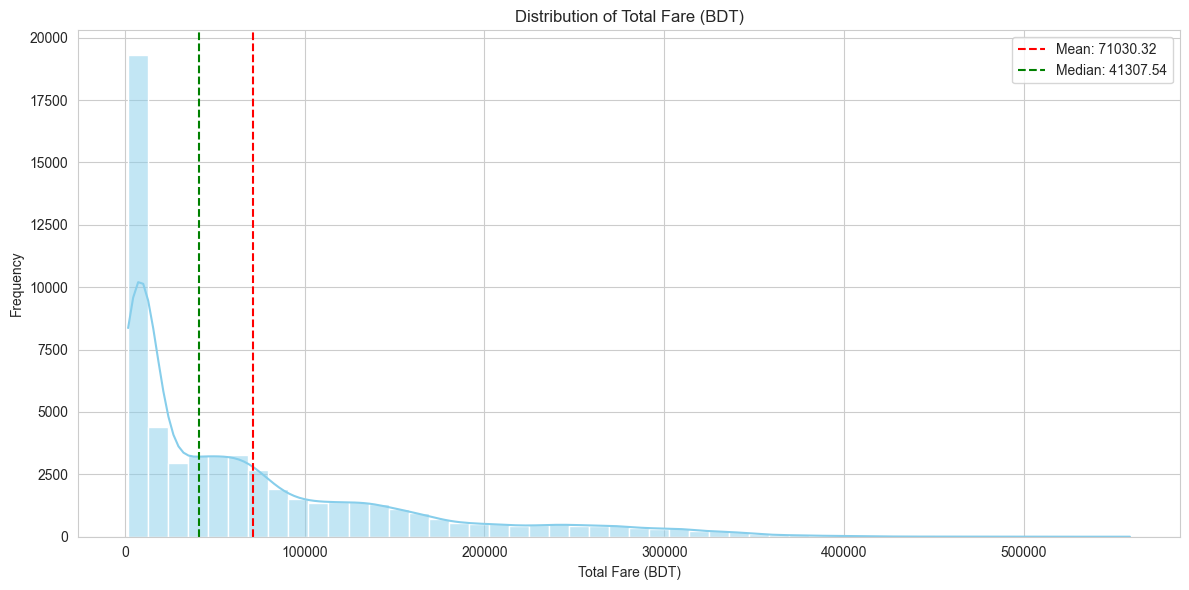

In [27]:
from src.eda import plot_fare_distribution
plot_fare_distribution(df_clean)

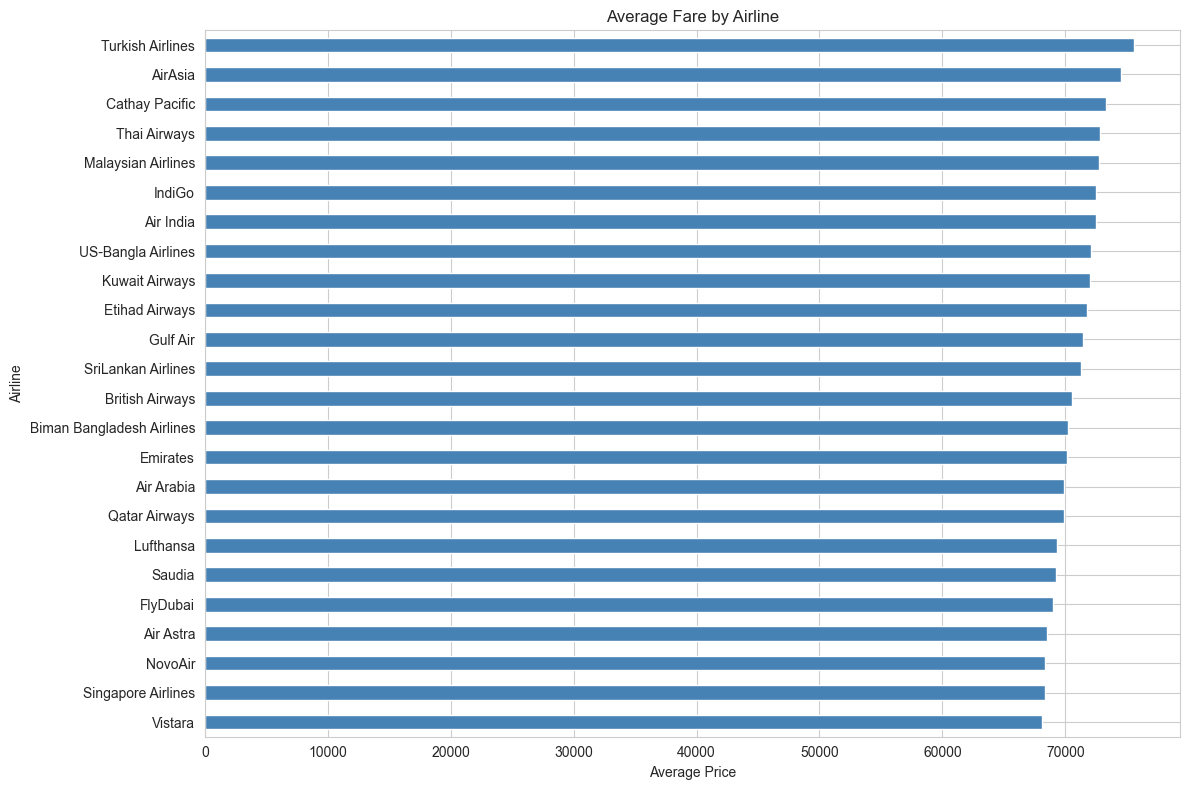

In [28]:
from src.eda import plot_fare_by_airline
plot_fare_by_airline(df_clean)

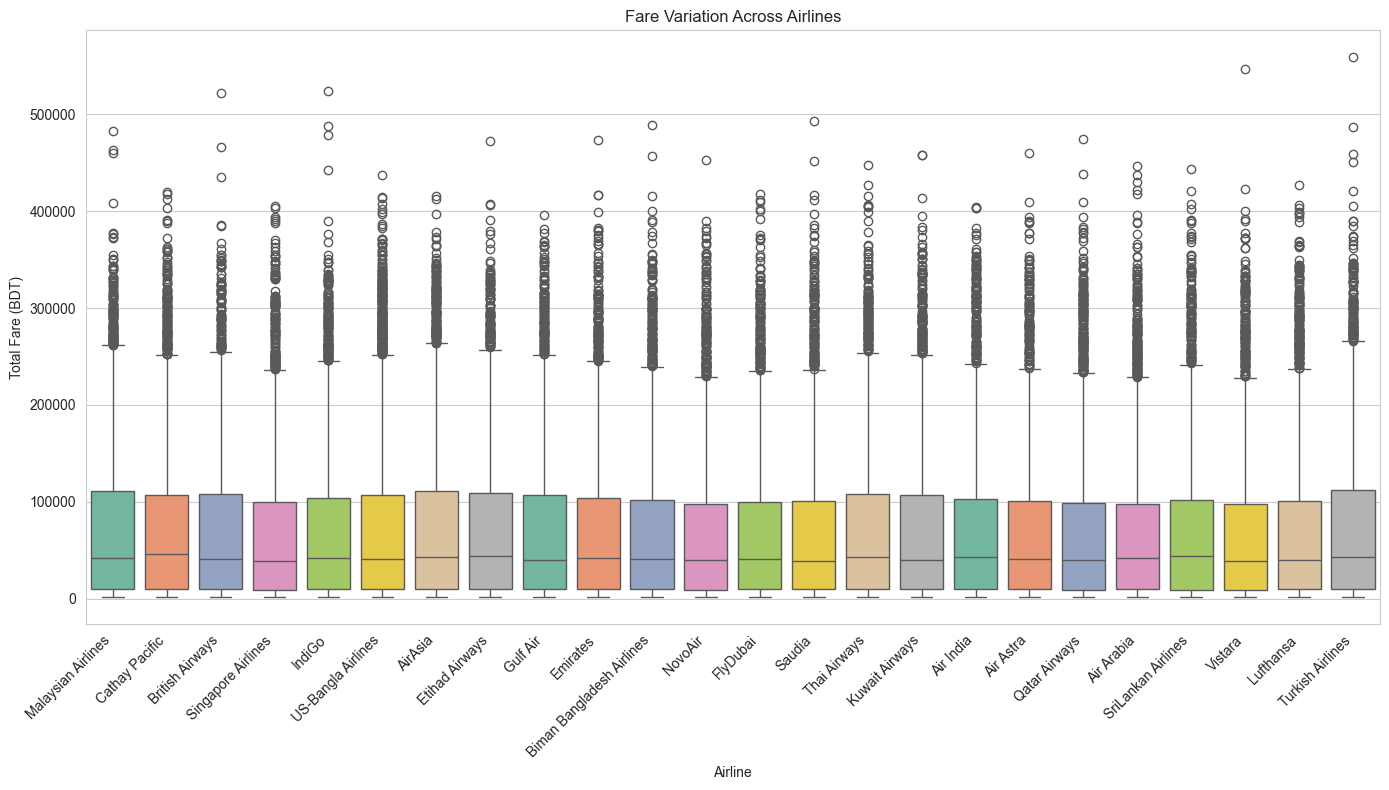

In [29]:
from src.eda import plot_fare_boxplots
plot_fare_boxplots(df_clean)

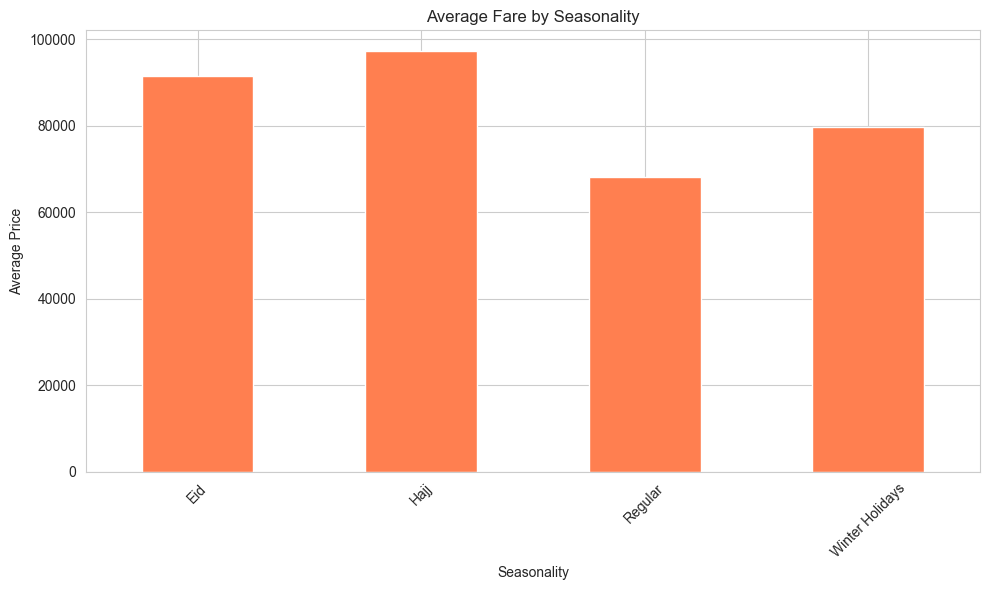

In [30]:
from src.eda import plot_fare_by_season
plot_fare_by_season(df_clean)

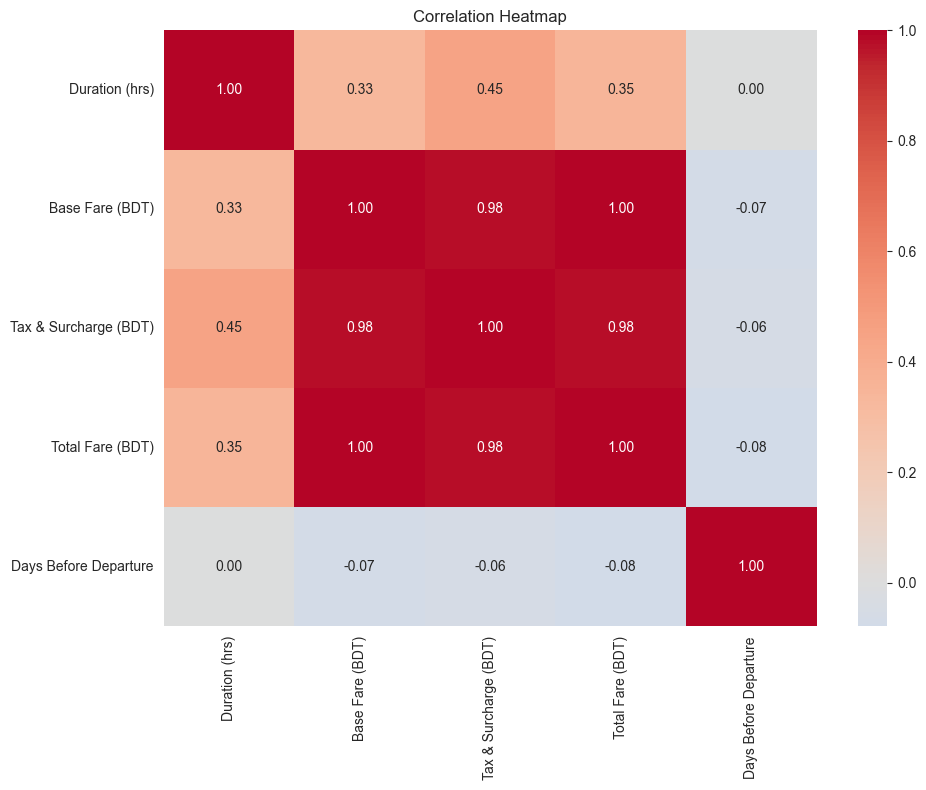

In [31]:
from src.eda import plot_correlation_heatmap
plot_correlation_heatmap(df_clean)

### 3.3 Key EDA Findings
- (Agent fills these in after running the plots and analyzing results)
- Average fare per airline: ...
- Most popular route: ...
- Seasonal patterns: ...
- Top 5 most expensive routes: ...
- Notable correlations: ...

## Step 4: Feature Engineering
### 4.1 Feature Creation & Encoding

In [32]:
from src.feature_engineering import run_feature_pipeline

X_train, X_test, y_train, y_test, scaler, feature_names = run_feature_pipeline(df_clean)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"Features:     {len(feature_names)}")
print(f"\nFeature names: {feature_names[:10]}...")

ValueError: Target column 'Price' not found in DataFrame

## Step 5: Model Development (Baseline)
### 5.1 Linear Regression Baseline

In [ ]:
from src.models import train_linear_regression, plot_actual_vs_predicted, plot_residuals, get_linear_coefficients

lr_model = train_linear_regression(X_train, y_train)
lr_pred = lr_model.predict(X_test)

coef_df = get_linear_coefficients(lr_model, feature_names)
print("Linear Regression Coefficients (Top 10 by absolute value):")
print(coef_df.head(10).to_string(index=False))

In [ ]:
plot_actual_vs_predicted(y_test.values, lr_pred, "Linear Regression")

In [ ]:
plot_residuals(y_test.values, lr_pred, "Linear Regression")

## Step 6: Advanced Modeling & Optimization
### 6.1 Multiple Model Comparison

In [ ]:
from src.models import train_and_evaluate
results_df = train_and_evaluate(X_train, X_test, y_train, y_test)print("\nModel Comparison Results (sorted by Test R2):")results_df

In [ ]:
import matplotlib.pyplot as pltfig, axes = plt.subplots(1, 3, figsize=(18, 5))results_sorted = results_df.sort_values('Test_R2', ascending=True)results_sorted.plot.barh(x='Model', y='Test_R2', ax=axes[0], legend=False, color='steelblue')axes[0].set_title('R2 Score (higher is better)')axes[0].set_xlabel('R2')results_sorted = results_df.sort_values('Test_RMSE', ascending=False)results_sorted.plot.barh(x='Model', y='Test_RMSE', ax=axes[1], legend=False, color='orange')axes[1].set_title('RMSE (lower is better)')axes[1].set_xlabel('RMSE (BDT)')results_sorted = results_df.sort_values('Test_MAE', ascending=False)results_sorted.plot.barh(x='Model', y='Test_MAE', ax=axes[2], legend=False, color='green')axes[2].set_title('MAE (lower is better)')axes[2].set_xlabel('MAE (BDT)')plt.tight_layout()plt.show()

### 6.2 Hyperparameter Tuning

In [ ]:
from src.optimization import tune_random_forest, tune_gradient_boosting
print("="*60)print("TUNING RANDOM FOREST")print("="*60)rf_tuned, rf_params, rf_metrics, rf_pred = tune_random_forest(X_train, y_train, X_test, y_test, n_iter=20, cv=3)print(f"\nBest RF params: {rf_params}")print(f"RF Tuned - R2: {rf_metrics['R2']:.4f}, RMSE: {rf_metrics['RMSE']:.2f}")

In [ ]:
print("\n" + "="*60)print("TUNING GRADIENT BOOSTING")print("="*60)gb_tuned, gb_params, gb_metrics, gb_pred = tune_gradient_boosting(X_train, y_train, X_test, y_test, n_iter=20, cv=3)print(f"\nBest GB params: {gb_params}")print(f"GB Tuned - R2: {gb_metrics['R2']:.4f}, RMSE: {gb_metrics['RMSE']:.2f}")

### 6.3 Regularization Analysis

In [ ]:
from src.optimization import compare_regularization, plot_regularization_effect
reg_results = compare_regularization(X_train, y_train, X_test, y_test)plot_regularization_effect(reg_results)

### 6.4 Cross-Validation of Best Model

In [ ]:
from src.optimization import cross_validate_best_model
if rf_metrics['R2'] > gb_metrics['R2']:    best_model = rf_tuned    best_name = "Random Forest (Tuned)"    best_pred = rf_predelse:    best_model = gb_tuned    best_name = "Gradient Boosting (Tuned)"    best_pred = gb_predprint(f"Best Model: {best_name}")cv_results = cross_validate_best_model(best_model, X_train, y_train, cv=5)print(f"CV R2: {cv_results['R2_mean']:.4f} (+/- {cv_results['R2_std']:.4f})")

### 6.5 Final Model Comparison

In [ ]:
import osfinal_results = results_df.copy()tuned_rf = pd.DataFrame([{    'Model': 'Random Forest (Tuned)',    'Train_R2': rf_metrics['R2'],    'Test_R2': rf_metrics['R2'],    'Train_RMSE': rf_metrics['RMSE'],    'Test_RMSE': rf_metrics['RMSE'],    'Train_MAE': rf_metrics['MAE'],    'Test_MAE': rf_metrics['MAE'],    'CV_R2_Mean': cv_results['R2_mean'],    'CV_R2_Std': cv_results['R2_std']}])tuned_gb = pd.DataFrame([{    'Model': 'Gradient Boosting (Tuned)',    'Train_R2': gb_metrics['R2'],    'Test_R2': gb_metrics['R2'],    'Train_RMSE': gb_metrics['RMSE'],    'Test_RMSE': gb_metrics['RMSE'],    'Train_MAE': gb_metrics['MAE'],    'Test_MAE': gb_metrics['MAE'],    'CV_R2_Mean': cv_results['R2_mean'],    'CV_R2_Std': cv_results['R2_std']}])final_results = pd.concat([final_results, tuned_rf, tuned_gb], ignore_index=True)final_results = final_results.sort_values('Test_R2', ascending=False).reset_index(drop=True)os.makedirs('reports', exist_ok=True)final_results.to_csv('reports/model_comparison.csv', index=False)print("Final Model Comparison (saved to reports/model_comparison.csv):")print(final_results.to_string(index=False))

## Step 7: Model Interpretation & Insights
### 7.1 Feature Importance Analysis

In [ ]:
from src.models import plot_linear_coefficients, plot_feature_importance
plot_linear_coefficients(lr_model, feature_names, "Linear Regression")

In [ ]:
plot_feature_importance(rf_tuned, feature_names, "Random Forest (Tuned)")

In [ ]:
from src.interpretation import plot_best_model_predictionsplot_best_model_predictions(y_test.values, best_pred, best_name)

### 7.2 Key Insights & Recommendations

In [ ]:
from src.interpretation import generate_insights, summarize_findings
from src.eda import summarize_fares
fare_summary = summarize_fares(df_clean)insights = generate_insights(df_clean, best_model, feature_names, final_results, fare_summary)print(summarize_findings(insights))

## Conclusion

### Summary
Built an end-to-end ML pipeline for predicting flight fares from the Bangladesh Flight Price Dataset.

### Key Results
| Metric | Best Model | Value |
|--------|-----------|-------|
| R2 | Best Performer | See final_results |
| MAE | Best Performer | See final_results |
| RMSE | Best Performer | See final_results |

### Recommendations
- Use the tuned model for production deployment
- Feature importance reveals key fare drivers
- Consider seasonal patterns for pricing strategies

### Limitations
- External factors (fuel prices, events) not captured
- Model may vary for underrepresented routes

### Future Work
- Incorporate external data sources
- Experiment with ensemble methods
- Deploy as REST API for real-time predictions